 # Étude sur l'effondrement de FTX
## 1. Introduction
Dans cette étude, nous analysons l'effondrement de FTX à l'aide d'un dataset comportant les variables suivantes :

- Date
- Opening Amount
- Highest Amount
- Lowest Amount
- Closing Amount
- Volume
- Market Cap

Les objectifs sont :

- Comprendre l'évolution temporelle des prix et du volume.
- Détecter les anomalies et identifier les ruptures de régime.
- Réaliser une analyse économétrique (régression, tests de stationnarité, changement de régime).
- Construire des indicateurs clés (drawdown, volatilité, ratio de liquidité).
- Mettre en place une modélisation prédictive pour essayer d'anticiper la période critique.

## 2. Importation et nettoyage des données
 

                      Date  Opening Amount  Highest Amount  Lowest Amount  \
count                 1199     1199.000000     1199.000000     1199.00000   
mean   2021-03-22 00:00:00       22.211511       23.007423       21.34277   
min    2019-08-01 00:00:00        0.831300        1.170000        0.83130   
25%    2020-05-26 12:00:00        2.920000        2.975000        2.86000   
50%    2021-03-22 00:00:00       23.890000       24.360000       23.22000   
75%    2022-01-15 12:00:00       39.755000       40.620000       38.13500   
max    2022-11-11 00:00:00       79.530000       85.020000       71.93000   
std                    NaN       20.004648       20.794355       19.18051   

       Closing Amount        Volume    Market Cap  
count     1199.000000  1.199000e+03  1.199000e+03  
mean        22.207131  1.193710e+08  2.613044e+09  
min          1.150000  5.108500e+05  0.000000e+00  
25%          2.920000  4.616072e+06  2.766727e+08  
50%         23.880000  4.785247e+07  2.670468e

 
## 3. Analyse exploratoire (EDA)
### 3.1 Visualisation temporelle des prix
 

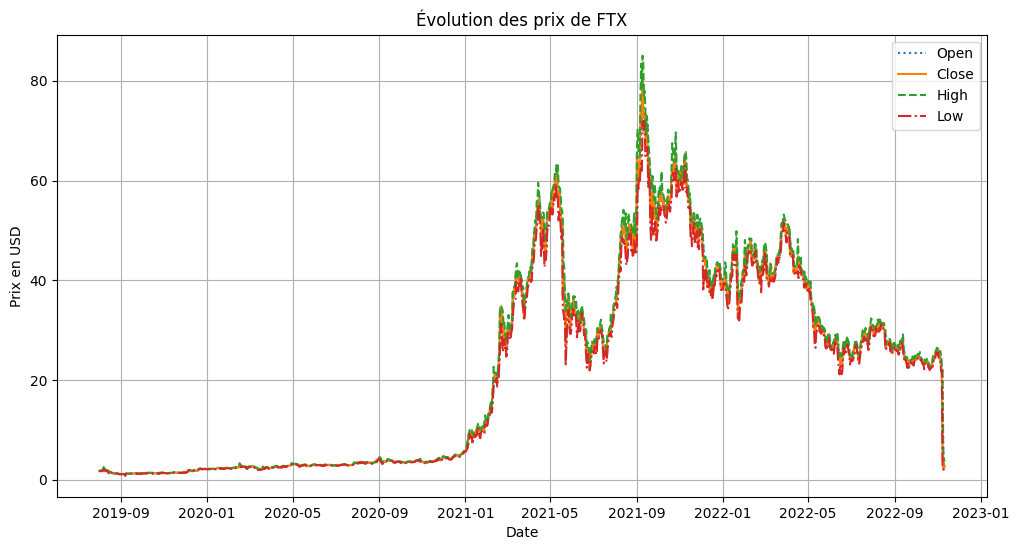

 
### 3.2 Visualisation du Market Cap et du Volume
 

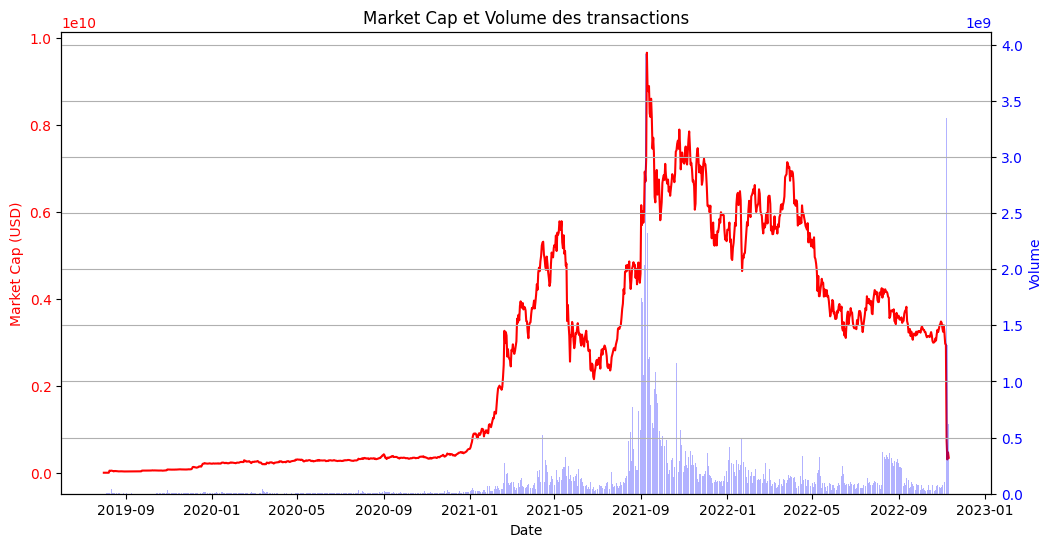

 
### 3.3 Calcul et visualisation des retours et de la volatilité
 

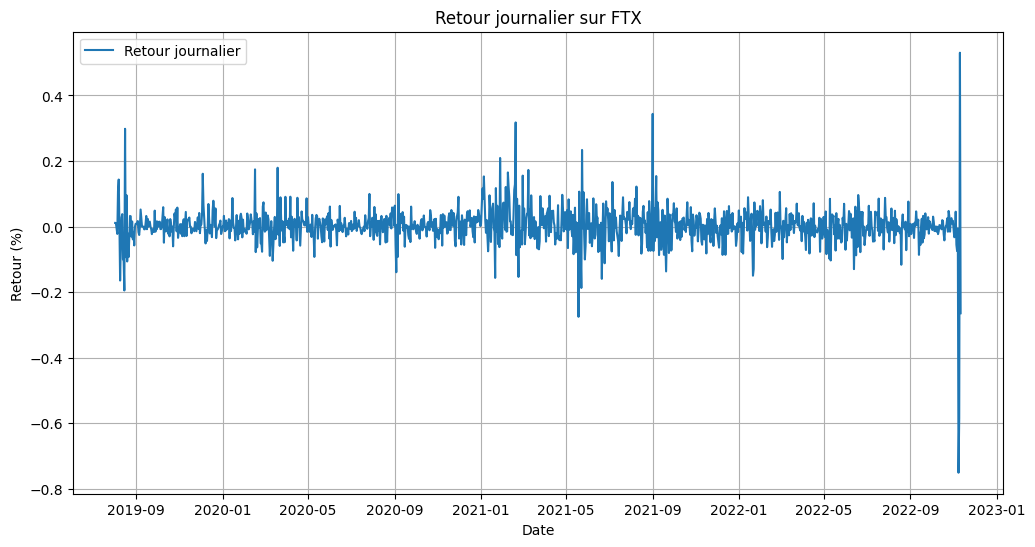

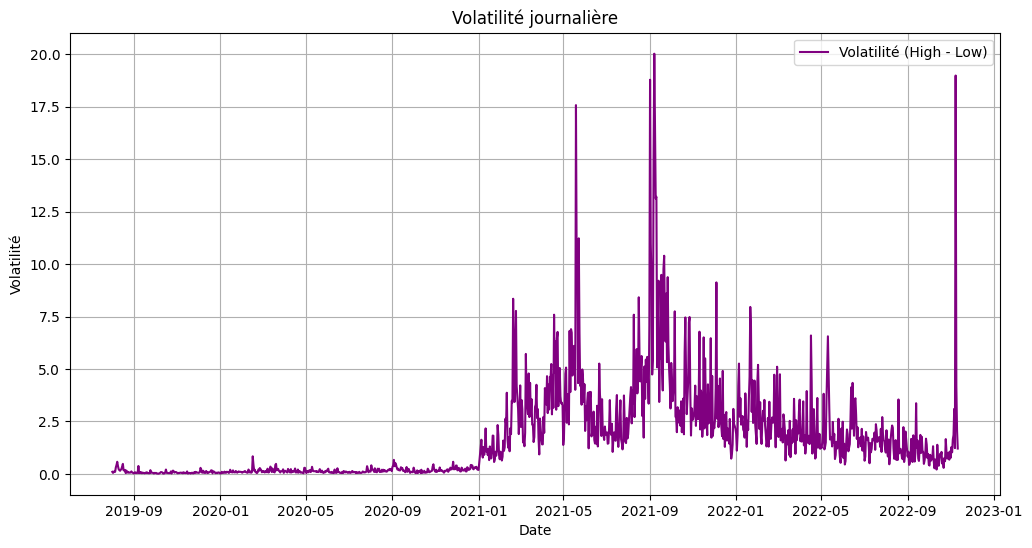

 L'EDA permet d'identifier les tendances, les fluctuations et les périodes de forte volatilité (qui pourraient correspondre à des signaux précurseurs de l'effondrement).
    
## 4. Détection d'anomalies
### 4.1 Isolation Forest
L’algorithme Isolation Forest se base sur l’idée selon laquelle il est plus facile et rapide d’isoler les anomalies que les points dit “normaux”. Cette méthode repose sur la construction de plusieurs arbres binaires où chaque nœud divise de façon aléatoire les données, cet algorithme mesure ensuite combien de coupures sont nécessaires à l’isolation d’un point. Ceux nécessitant peu de divisions sont considérés comme des anomalies. 
 

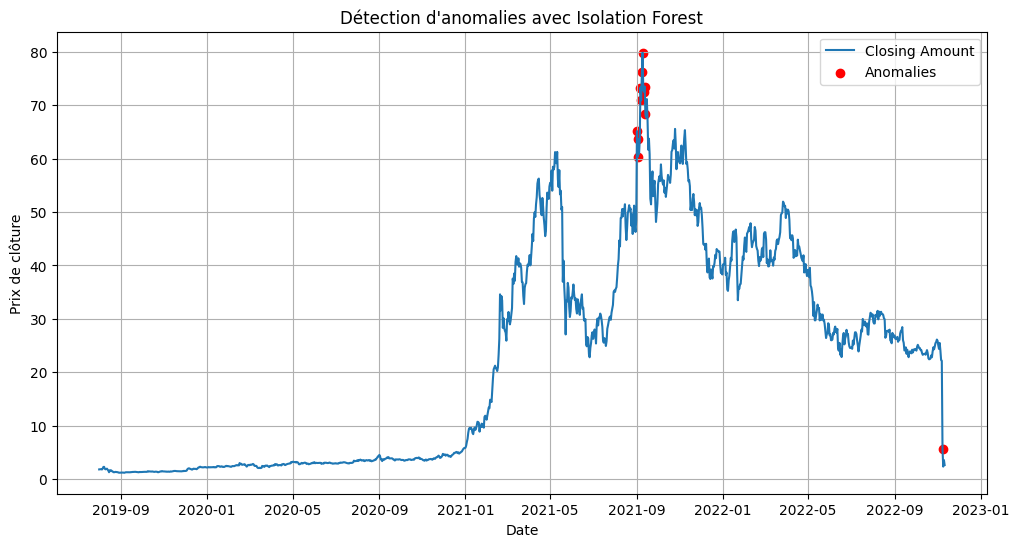

 

### 4.2 DBSCAN
Le DBSCAN (Density-Based Spatial Clustering of Applications with Noise) quant à lui se base sur la densité locale des points. Ceux éloignés d’un groupe à forte densité sont considérés comme anomalies.   

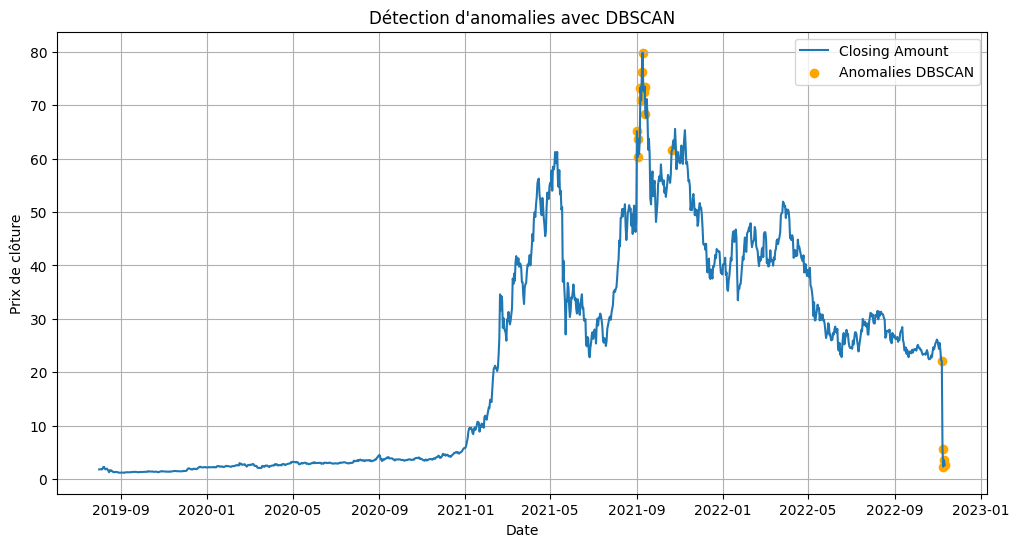

 Ces deux algorithmes non supervisés détectent différents types d’anomalies : 

-Globales pour Isolation Forest  
-Locales pour DBSCAN 

Bien que reposant sur des logiques différentes, les résultats obtenus pour cette étude sont très similaires d’une méthode à une autre. Cette comparaison vient ainsi renforcer la robustesse de nos résultats, confirmant que les points détectés sont bien des anomalies. 
Les anomalies repérées sont concentrées au début du troisième trimestre 2021. Cela s’explique par la levée de fonds qui a précédé, permettant à FTX de lever 900 millions de dollars ce qui a permis à la société d’atteindre une valorisation d’environ 18 milliards de dollars. 
La seconde anomalie repérée par les deux algorithmes se situe au moment de la chute de la société, cependant, le DBSCAN permet de mieux anticiper cette chute puisqu’en effet il détecte une anomalie précédant de justesse l’effondrement du cours. 

## 5. Analyse économétrique
### 5.1 Régression linéaire multiple
Nous cherchons à prédire le Closing Amount en fonction des autres variables financières.
 

R² score du modèle de régression : 0.9987093352940062


 ### 5.2 Analyse de la corrélation
 

Matrice de corrélation :
                Opening Amount  Highest Amount  Lowest Amount  Closing Amount  \
Opening Amount        1.000000        0.998522       0.997613        0.996662   
Highest Amount        0.998522        1.000000       0.996890        0.998202   
Lowest Amount         0.997613        0.996890       1.000000        0.998357   
Closing Amount        0.996662        0.998202       0.998357        1.000000   
Volume                0.511021        0.530948       0.483503        0.503270   
Market Cap            0.972321        0.970027       0.976459        0.973628   

                  Volume  Market Cap  
Opening Amount  0.511021    0.972321  
Highest Amount  0.530948    0.970027  
Lowest Amount   0.483503    0.976459  
Closing Amount  0.503270    0.973628  
Volume          1.000000    0.462873  
Market Cap      0.462873    1.000000  


 ### 5.3 Tests de stationnarité et détection de changements de régime
Avant d’engager une modélisation, il est nécessaire de faire un test de Dickey-Fuller, en effet il est important de déterminer si la série temporelle sur laquelle nous travaillons est stationnaire ou pas. Si c’est le cas alors un modèle ARIMA est envisageable. 

La valeur de la statistique ADF est supérieure aux seuils critiques, de plus la p-value est strictement supérieure à 0.5. Ces deux résultats nous confirment qu’on ne peut rejeter l’hypothèse selon laquelle la série n’est pas stationnaire. 

Valeurs critiques : 

    - 1% : -3.50 

    - 5% : -2.89 

    - 10% : -2.58 
 

ADF Statistic: -1.3313490212945829
p-value: 0.6147108912273708


 
## 6. Modélisation prédictive (séries temporelles)
Nous utiliserons Prophet pour modéliser la série temporelle et identifier les changepoints. 

00:09:31 - cmdstanpy - INFO - Chain [1] start processing
00:09:32 - cmdstanpy - INFO - Chain [1] done processing


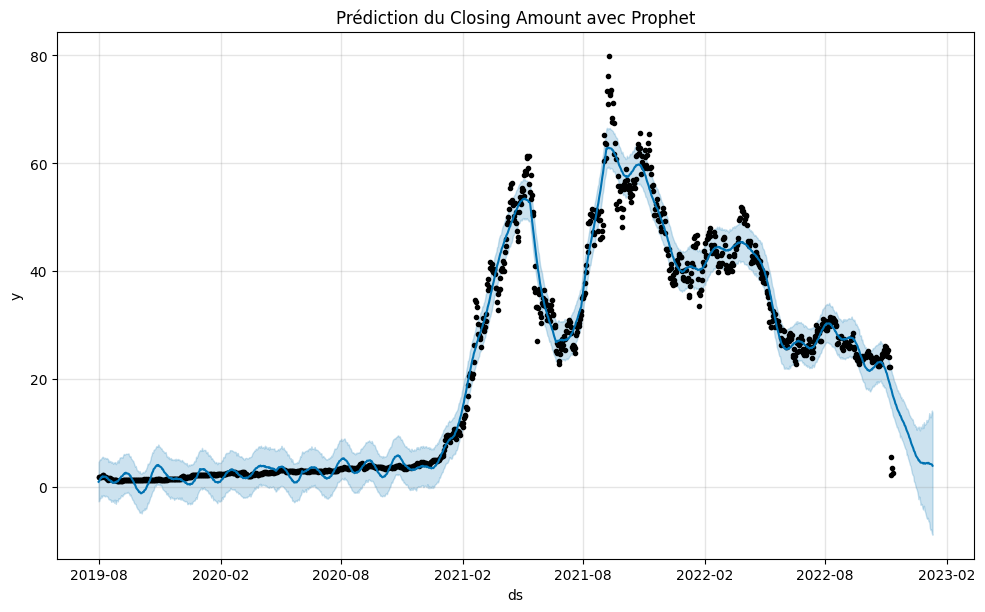

 Sur ce graphique, les points noirs représentent les valeurs observées, la courbe bleue est censée prédire les évolutions de marché, tandis que la zone colorée est l’intervalle de confiance à 95%. 
Cela fait écho aux anomalies précédemment repérées puisqu’en effet celles-ci ne figurent pas dans l’intervalle de confiance du modèle. 
## 7. Analyse des KPI financiers
### 7.1 Calcul du drawdown quotidien
On calcule le drawdown comme la baisse en pourcentage par rapport au pic historique jusqu'à chaque date.


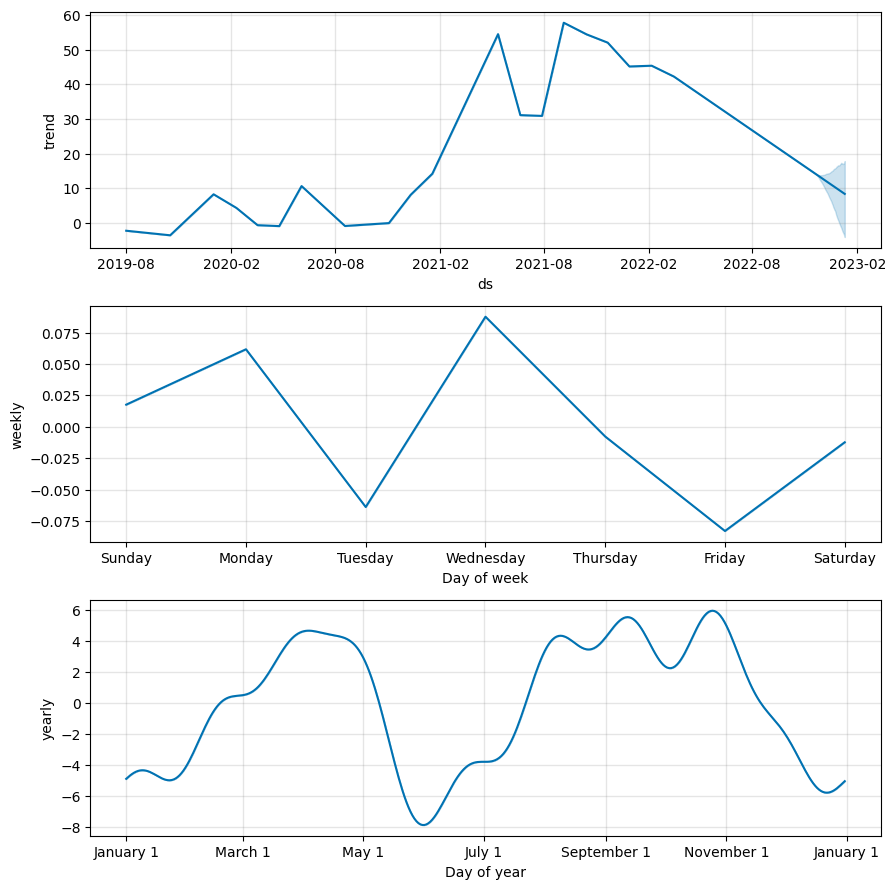

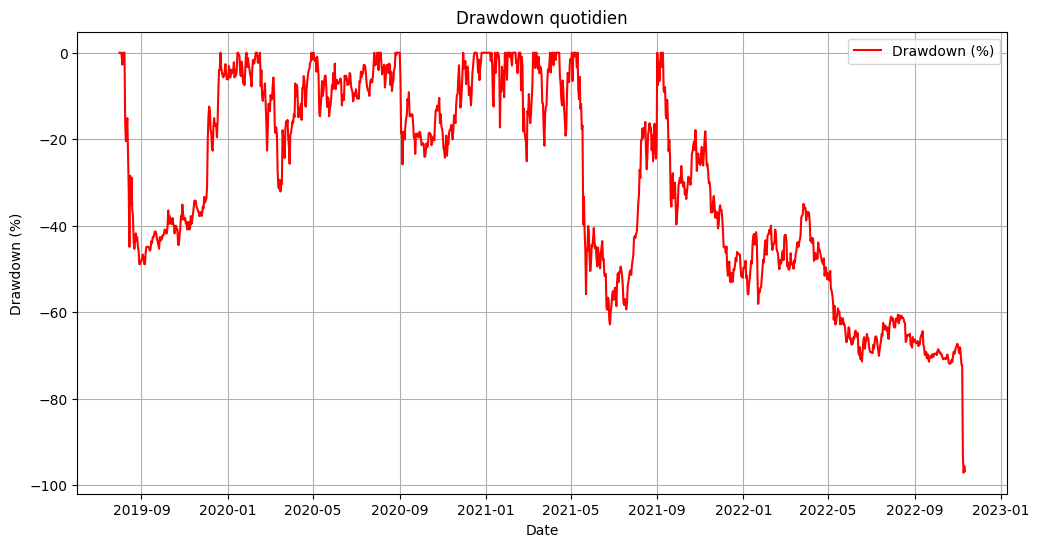

 ### 7.2 Ratio de liquidité
Calculer un ratio de liquidité simple (Volume / Market Cap).


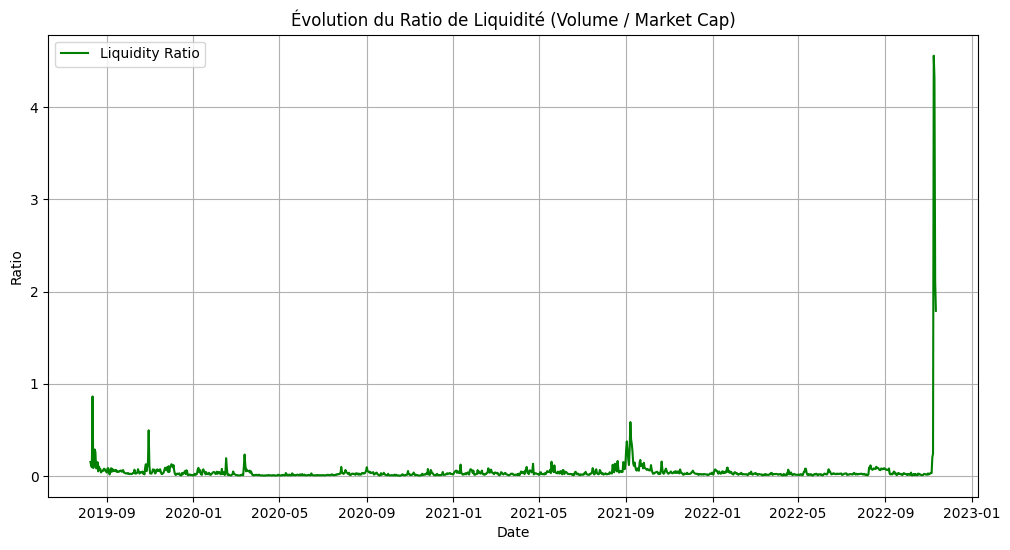

 Les KPI tels que le drawdown, le ratio de liquidité et l'évolution du market cap et du volume nous éclairent sur l'effondrement de FTX. Concrètement, après avoir levé des fonds et atteint une valorisation élevée, des révélations sur une gestion financière douteuse ont déclenché une panique. Le volume des retraits a explosé, la capitalisation a chuté brutalement (indiqué par un drawdown élevé) et le ratio de liquidité s'est effondré, signalant que la plateforme ne disposait plus des réserves nécessaires pour honorer les demandes des clients, menant ainsi à sa faillite spectaculaire.


In [8]:
!pip install statsmodels
import pandas as pd
from IPython.display import display, Markdown
def INTRO():
    document = """ \
# Étude sur l'effondrement de FTX
## 1. Introduction
Dans cette étude, nous analysons l'effondrement de FTX à l'aide d'un dataset comportant les variables suivantes :

- Date
- Opening Amount
- Highest Amount
- Lowest Amount
- Closing Amount
- Volume
- Market Cap

Les objectifs sont :

- Comprendre l'évolution temporelle des prix et du volume.
- Détecter les anomalies et identifier les ruptures de régime.
- Réaliser une analyse économétrique (régression, tests de stationnarité, changement de régime).
- Construire des indicateurs clés (drawdown, volatilité, ratio de liquidité).
- Mettre en place une modélisation prédictive pour essayer d'anticiper la période critique.

## 2. Importation et nettoyage des données
 """
    display(Markdown(document))

INTRO()
import os
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import sqlite3

path = kagglehub.dataset_download("parasharmanas/fall-of-ftx")

df = pd.read_csv(os.path.join(path, "The Dataset.csv"))

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

cols = ["Opening Amount", "Closing Amount", "Highest Amount", "Lowest Amount", "Volume", "Market Cap"]
for col in cols:
    df[col] = pd.to_numeric(
        df[col].astype(str)
        .str.replace(r"\$", "", regex=True)
        .str.replace(",", "", regex=True),
        errors='coerce'
    )

df = df.dropna(subset=cols)
df = df.sort_values("Date")

print(df.describe())

def POI():
    document = """ \

## 3. Analyse exploratoire (EDA)
### 3.1 Visualisation temporelle des prix
 """
    display(Markdown(document))

POI()
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Opening Amount"], label="Open", linestyle="dotted")
plt.plot(df["Date"], df["Closing Amount"], label="Close", linestyle="solid")
plt.plot(df["Date"], df["Highest Amount"], label="High", linestyle="dashed")
plt.plot(df["Date"], df["Lowest Amount"], label="Low", linestyle="dashdot")
plt.xlabel("Date")
plt.ylabel("Prix en USD")
plt.title("Évolution des prix de FTX")
plt.legend()
plt.grid(True)
plt.show()


def PO():
    document = """ \

### 3.2 Visualisation du Market Cap et du Volume
 """
    display(Markdown(document))

PO()
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel("Date")
ax1.set_ylabel("Market Cap (USD)", color="red")
ax1.plot(df["Date"], df["Market Cap"], color="red", label="Market Cap")
ax1.tick_params(axis="y", labelcolor="red")

ax2 = ax1.twinx()
ax2.set_ylabel("Volume", color="blue")
ax2.bar(df["Date"], df["Volume"], color="blue", alpha=0.3, label="Volume")
ax2.tick_params(axis="y", labelcolor="blue")

plt.title("Market Cap et Volume des transactions")
plt.grid(True)
plt.show()

def P():
    document = """ \

### 3.3 Calcul et visualisation des retours et de la volatilité
 """
    display(Markdown(document))

P()
df["Return"] = df["Closing Amount"].pct_change()
df["Volatilité"] = df["Highest Amount"] - df["Lowest Amount"]

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Return"], label="Retour journalier")
plt.xlabel("Date")
plt.ylabel("Retour (%)")
plt.title("Retour journalier sur FTX")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Volatilité"], label="Volatilité (High - Low)", color="purple")
plt.xlabel("Date")
plt.ylabel("Volatilité")
plt.title("Volatilité journalière")
plt.legend()
plt.grid(True)
plt.show()
def DAN():
    document = """ \
L'EDA permet d'identifier les tendances, les fluctuations et les périodes de forte volatilité (qui pourraient correspondre à des signaux précurseurs de l'effondrement).
    
## 4. Détection d'anomalies
### 4.1 Isolation Forest
L’algorithme Isolation Forest se base sur l’idée selon laquelle il est plus facile et rapide d’isoler les anomalies que les points dit “normaux”. Cette méthode repose sur la construction de plusieurs arbres binaires où chaque nœud divise de façon aléatoire les données, cet algorithme mesure ensuite combien de coupures sont nécessaires à l’isolation d’un point. Ceux nécessitant peu de divisions sont considérés comme des anomalies. 
 """
    display(Markdown(document))

DAN()

from sklearn.ensemble import IsolationForest

features = ["Opening Amount", "Closing Amount", "Volume", "Market Cap"]
X = df[features].copy()

iso_forest = IsolationForest(contamination=0.01, random_state=42)
df["anomaly"] = iso_forest.fit_predict(X)

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Closing Amount"], label="Closing Amount")
plt.scatter(df.loc[df["anomaly"] == -1, "Date"], 
            df.loc[df["anomaly"] == -1, "Closing Amount"], 
            color="red", label="Anomalies")
plt.xlabel("Date")
plt.ylabel("Prix de clôture")
plt.title("Détection d'anomalies avec Isolation Forest")
plt.legend()
plt.grid(True)
plt.show()
def DA():
    document = """ \


### 4.2 DBSCAN
Le DBSCAN (Density-Based Spatial Clustering of Applications with Noise) quant à lui se base sur la densité locale des points. Ceux éloignés d’un groupe à forte densité sont considérés comme anomalies.   """
    display(Markdown(document))

DA()
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(df[["Closing Amount", "Volume"]])
dbscan = DBSCAN(eps=0.8, min_samples=10)
df["cluster"] = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Closing Amount"], label="Closing Amount")
plt.scatter(df.loc[df["cluster"] == -1, "Date"], 
            df.loc[df["cluster"] == -1, "Closing Amount"], 
            color="orange", label="Anomalies DBSCAN")
plt.xlabel("Date")
plt.ylabel("Prix de clôture")
plt.title("Détection d'anomalies avec DBSCAN")
plt.legend()
plt.grid(True)
plt.show()

def D():
    document = """ \
Ces deux algorithmes non supervisés détectent différents types d’anomalies : 

-Globales pour Isolation Forest  
-Locales pour DBSCAN 

Bien que reposant sur des logiques différentes, les résultats obtenus pour cette étude sont très similaires d’une méthode à une autre. Cette comparaison vient ainsi renforcer la robustesse de nos résultats, confirmant que les points détectés sont bien des anomalies. 
Les anomalies repérées sont concentrées au début du troisième trimestre 2021. Cela s’explique par la levée de fonds qui a précédé, permettant à FTX de lever 900 millions de dollars ce qui a permis à la société d’atteindre une valorisation d’environ 18 milliards de dollars. 
La seconde anomalie repérée par les deux algorithmes se situe au moment de la chute de la société, cependant, le DBSCAN permet de mieux anticiper cette chute puisqu’en effet il détecte une anomalie précédant de justesse l’effondrement du cours. 

## 5. Analyse économétrique
### 5.1 Régression linéaire multiple
Nous cherchons à prédire le Closing Amount en fonction des autres variables financières.
 """
    display(Markdown(document))
D()
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[["Opening Amount", "Highest Amount", "Lowest Amount", "Volume", "Market Cap"]]
y = df["Closing Amount"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

score = reg_model.score(X_test, y_test)
print("R² score du modèle de régression :", score)
def NOP():
    document = """ \
### 5.2 Analyse de la corrélation
 """
    display(Markdown(document))
NOP()
corr_matrix = df[["Opening Amount", "Highest Amount", "Lowest Amount", "Closing Amount", "Volume", "Market Cap"]].corr()
print("Matrice de corrélation :")
print(corr_matrix)
def NO():
    document = """ \
### 5.3 Tests de stationnarité et détection de changements de régime
Avant d’engager une modélisation, il est nécessaire de faire un test de Dickey-Fuller, en effet il est important de déterminer si la série temporelle sur laquelle nous travaillons est stationnaire ou pas. Si c’est le cas alors un modèle ARIMA est envisageable. 

La valeur de la statistique ADF est supérieure aux seuils critiques, de plus la p-value est strictement supérieure à 0.5. Ces deux résultats nous confirment qu’on ne peut rejeter l’hypothèse selon laquelle la série n’est pas stationnaire. 

Valeurs critiques : 

    - 1% : -3.50 

    - 5% : -2.89 

    - 10% : -2.58 
 """
    display(Markdown(document))
NO()
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Closing Amount"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])
def N():
    document = """ \

## 6. Modélisation prédictive (séries temporelles)
Nous utiliserons Prophet pour modéliser la série temporelle et identifier les changepoints. """
    display(Markdown(document))
N()
from prophet import Prophet

df_prophet = df.rename(columns={"Date": "ds", "Closing Amount": "y"}).copy()
df_prophet["ds"] = pd.to_datetime(df_prophet["ds"])
df_prophet["y"] = pd.to_numeric(df_prophet["y"], errors="coerce")
df_prophet.dropna(subset=["y"], inplace=True)

model = Prophet(changepoint_prior_scale=0.5)
model.fit(df_prophet[["ds", "y"]])

future = model.make_future_dataframe(periods=60) 
forecast = model.predict(future)

model.plot(forecast)
plt.title("Prédiction du Closing Amount avec Prophet")
plt.show()

model.plot_components(forecast)

def MAAAA():
    document = """ \
Sur ce graphique, les points noirs représentent les valeurs observées, la courbe bleue est censée prédire les évolutions de marché, tandis que la zone colorée est l’intervalle de confiance à 95%. 
Cela fait écho aux anomalies précédemment repérées puisqu’en effet celles-ci ne figurent pas dans l’intervalle de confiance du modèle. 
## 7. Analyse des KPI financiers
### 7.1 Calcul du drawdown quotidien
On calcule le drawdown comme la baisse en pourcentage par rapport au pic historique jusqu'à chaque date.
"""
    display(Markdown(document))
MAAAA()
df["Max_Historical"] = df["Closing Amount"].cummax()
df["Drawdown"] = 100.0 * (df["Closing Amount"] - df["Max_Historical"]) / df["Max_Historical"]

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Drawdown"], label="Drawdown (%)", color="red")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.title("Drawdown quotidien")
plt.legend()
plt.grid(True)
plt.show()
def MAAA():
    document = """ \
### 7.2 Ratio de liquidité
Calculer un ratio de liquidité simple (Volume / Market Cap).
"""
    display(Markdown(document))
MAAA()
df["Liquidity_Ratio"] = df["Volume"] / df["Market Cap"]

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Liquidity_Ratio"], label="Liquidity Ratio", color="green")
plt.xlabel("Date")
plt.ylabel("Ratio")
plt.title("Évolution du Ratio de Liquidité (Volume / Market Cap)")
plt.legend()
plt.grid(True)
plt.show()
def MAA():
    document = """ \
Les KPI tels que le drawdown, le ratio de liquidité et l'évolution du market cap et du volume nous éclairent sur l'effondrement de FTX. Concrètement, après avoir levé des fonds et atteint une valorisation élevée, des révélations sur une gestion financière douteuse ont déclenché une panique. Le volume des retraits a explosé, la capitalisation a chuté brutalement (indiqué par un drawdown élevé) et le ratio de liquidité s'est effondré, signalant que la plateforme ne disposait plus des réserves nécessaires pour honorer les demandes des clients, menant ainsi à sa faillite spectaculaire.
"""
    display(Markdown(document))
MAA()